### ⭐ Step 1 - Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### ⭐ Step 2 - Load Dataset

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

### ⭐ Step 3 - Inspect Data, Missingness, Dtypes

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### ⭐ Step 4 - Handle Missing Values

In [16]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna("Unknown")


In [19]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

### ⭐ Step 5 - Create Age Buckets

In [20]:
bins = [0, 12, 18, 50, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)


### ⭐ Step 6 - Survival By Sex (Bar Chart)

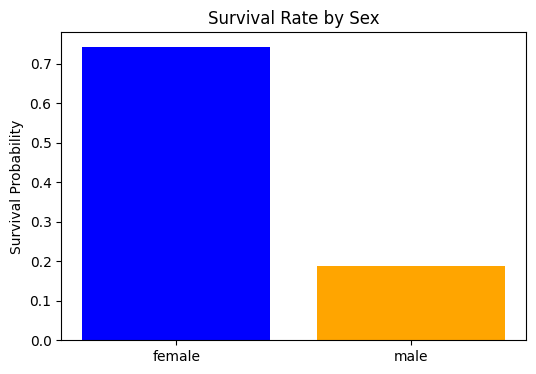

In [23]:
surv_sex = df.groupby('Sex')['Survived'].mean()

plt.figure(figsize=(6,4))
plt.bar(surv_sex.index, surv_sex.values, color=['blue','orange'])
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Probability")
plt.savefig("outputs/survival_by_sex.png")
plt.show()

## 🔍 Key Observations:

- Female passengers had a much higher survival probability (~74%) compared to males.

- Male survival probability is very low (~19%), indicating that most male passengers did not survive.

- This strong difference reflects the evacuation rule “women and children first”, which was strictly followed during the Titanic disaster.

- The chart clearly shows gender as one of the strongest predictors of survival on the Titanic.

### ⭐ Step 7 - Survival By Class (Bar Chart)

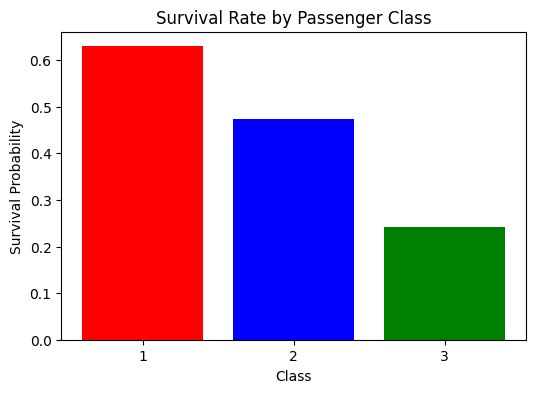

In [43]:
surv_class = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(6,4))
plt.bar(surv_class.index.astype(str), surv_class.values, color=['red','blue','green'])
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Class")
plt.ylabel("Survival Probability")
plt.savefig("outputs/survival_by_class.png")
plt.show()


## 🔍 Key Observations:

- 1st Class passengers had the highest survival rate (~63%), showing they received better access to lifeboats and evacuation support.

- 2nd Class passengers had a moderate survival rate (~48%), indicating some priority but not as strong as 1st Class.

- 3rd Class passengers had the lowest survival rate (~24%), revealing they were at a major disadvantage during the evacuation.

- The strong downward trend from Class 1 → Class 3 highlights how socio-economic status played a major role in determining survival chances on the Titanic.

### ⭐ Step 8 - Survival By Age Group (Bar Chart)

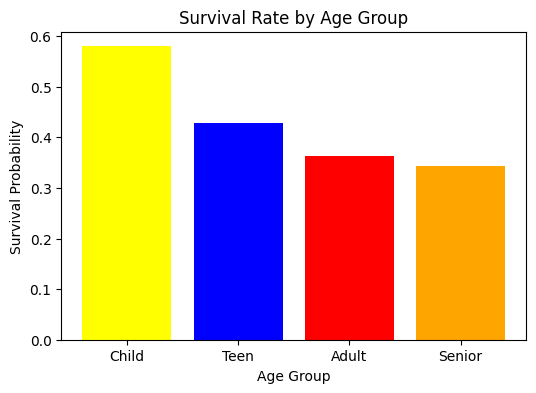

In [44]:
surv_age = df.groupby('Age_Group', observed=False)['Survived'].mean()

plt.figure(figsize=(6,4))
plt.bar(surv_age.index.astype(str), surv_age.values, color=['yellow','blue','red','orange'])
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Probability")
plt.savefig("outputs/survival_by_age.png")
plt.show()


## 🔍 Key Observations:

- Children have the highest survival rate (~58%), indicating strong priority was given to young passengers during evacuation.

- Teenagers also show a relatively high survival rate (~43%), higher than adults and seniors.

- Adults have a lower survival probability (~36%), suggesting they did not receive the same priority as younger passengers.

- Seniors have the lowest survival rate (~34%), reflecting both limited mobility and lower evacuation priority.

- Overall, the trend shows a clear decline in survival probability with increasing age, reinforcing the “women and children first” evacuation pattern.

### ⭐ Step 9 - Boxplot: Age vs Survival

<Figure size 600x400 with 0 Axes>

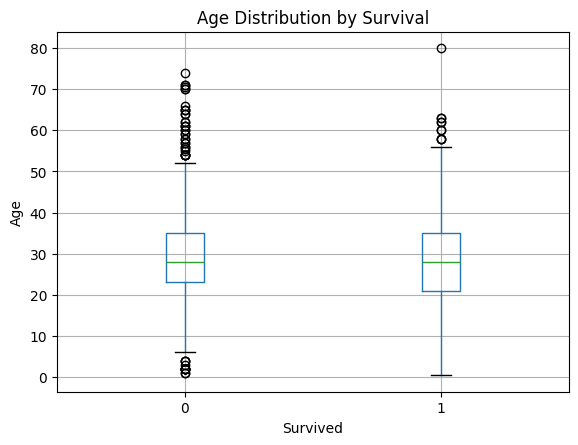

In [45]:
plt.figure(figsize=(6,4))
df.boxplot(column='Age', by='Survived')
plt.title("Age Distribution by Survival")
plt.suptitle("")  # remove extra title
plt.xlabel("Survived")
plt.ylabel("Age")
plt.savefig("outputs/age_survival_boxplot.png")
plt.show()


## 🔍 Key Observations:

- Survivors tend to be younger on average compared to non-survivors.

- The median age of survivors is lower than the median age of those who did not survive, indicating that younger passengers had better survival chances.

- There are many older passengers (50+ years) among the non-survivors, showing seniors faced greater difficulty during evacuation.

- The boxplot shows wide age variability in both groups - but the survivor group contains more young passengers, including children.

- Outliers in both categories show that a few infants and elderly passengers survived, but they are exceptions.

### ⭐ Step 10 - Violin Plot

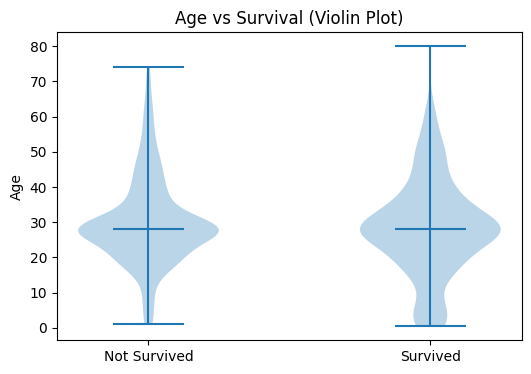

In [48]:
survived = df[df['Survived'] == 1]['Age']
not_survived = df[df['Survived'] == 0]['Age']

plt.figure(figsize=(6,4))
plt.violinplot([not_survived, survived], showmedians=True)
plt.xticks([1,2], ["Not Survived", "Survived"])
plt.title("Age vs Survival (Violin Plot)")
plt.ylabel("Age")
plt.savefig("outputs/age_survival_violin.png")
plt.show()


## 🔍 Key Observations:

- The survivor distribution is more concentrated around younger ages, showing more children and young adults survived.

- The non-survivor group has a wider spread, especially among adults and seniors, indicating higher death rates in older age groups.

- Both survivors and non-survivors include a few infants and elderly passengers, but these are rare outliers.

- The median age of survivors is slightly lower than that of non-survivors, reinforcing the age advantage for survival.

- Overall, the violin plot confirms that younger passengers had a higher likelihood of survival, consistent with evacuation priorities.

### ⭐ Step 11 - Save Cleaned Dataset

In [49]:
df.to_csv("outputs/Titanic_Cleaned.csv", index=False)

## ⭐ Step 12 - Final Insights Summary

- emale passengers had significantly higher survival rates than males, highlighting the strong impact of the “women and children first” evacuation rule.

- 1st Class passengers survived at much higher rates than 2nd and 3rd Class, showing that socio-economic status played a major role in survival chances.

- Children had the highest survival probability among all age groups, while adults and seniors showed noticeably lower survival rates.

- Boxplot and violin plot analyses reveal that survivors were generally younger, with non-survivors displaying a wider age spread across older age groups.

- Overall, gender, passenger class, and age were the strongest predictors of survival, making them key factors in understanding Titanic survival patterns.